In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
## Class Imbalance Analysis
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
fraud = df[df['Class']==1]
normal = df[df['Class']==0]
print("Fraud Transactions :", len(fraud))
print("Normal Transactions :", len(normal))

Fraud Transactions : 492
Normal Transactions : 284315


In [11]:
fraud_percent = (len(fraud)/len(df))*100

print("Fraud Percentage = {:.4f}%".format(fraud_percent))

Fraud Percentage = 0.1727%


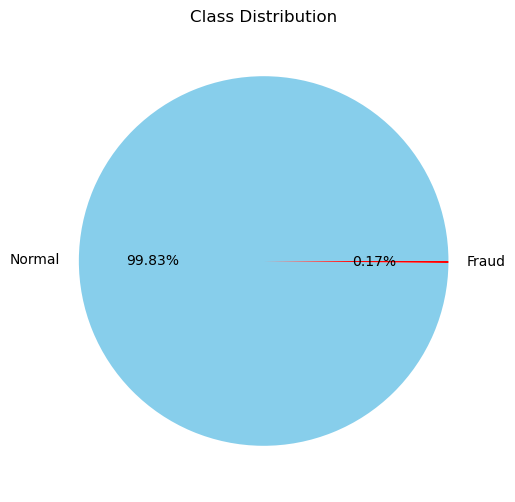

In [12]:
plt.figure(figsize=(6,6))
plt.pie(df['Class'].value_counts(),
        labels=['Normal','Fraud'],
        autopct='%1.2f%%',
        colors=['skyblue','red'])

plt.title("Class Distribution")
plt.show()

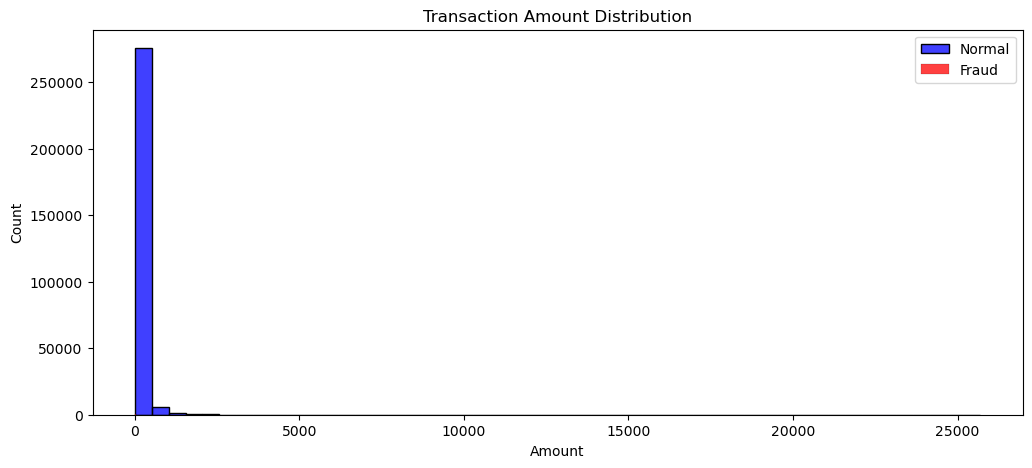

In [13]:
## Transaction Amount Distribution
plt.figure(figsize=(12,5))
sns.histplot(normal['Amount'],
             bins=50,
             color='blue',
             label='Normal')

sns.histplot(fraud['Amount'],
             bins=50,
             color='red',
             label='Fraud')
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

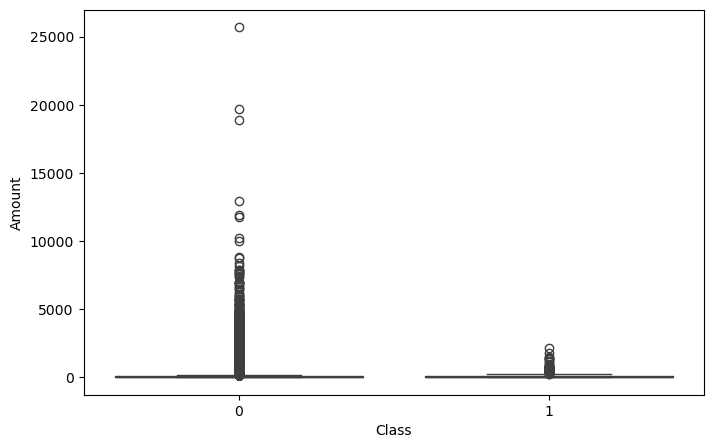

In [14]:
## Fraud vs Normal Boxplot

plt.figure(figsize=(8,5))
sns.boxplot(x='Class',
            y='Amount',
            data=df)

plt.show()

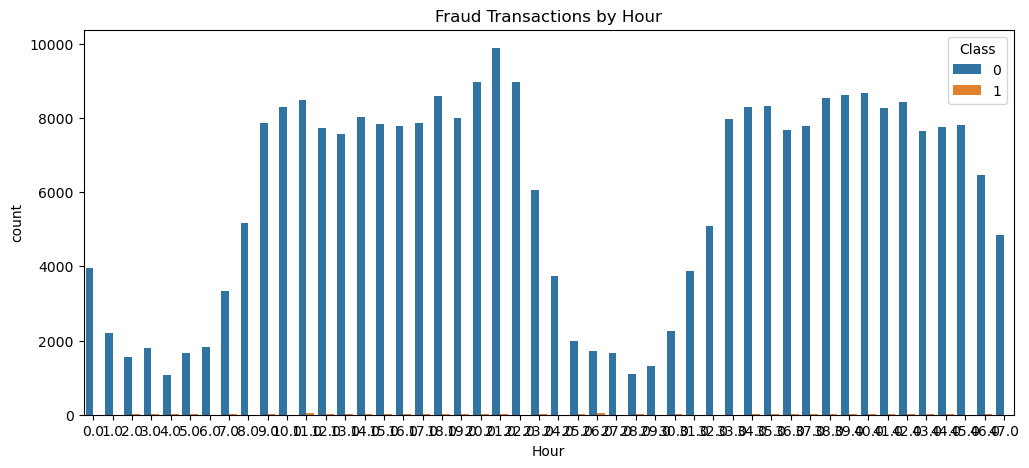

In [17]:
# Time Analysis
df['Hour'] = (df['Time']//3600)%241

plt.figure(figsize=(12,5))
sns.countplot(x='Hour',
              hue='Class',
              data=df)

plt.title("Fraud Transactions by Hour")
plt.show()

In [20]:
# Feature Scaling

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df.drop('Time', axis=1, inplace=True)

In [21]:
# Split Features

X = df.drop("Class", axis=1)
y = df["Class"]

In [22]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [24]:
pd.Series(y_train_smote).value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [25]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

In [30]:
rf_pred = lr.predict(X_test)

rf_prob = lr.predict_proba(X_test)[:,1]

In [31]:
# Evaluation
print("Accuracy :",accuracy_score(y_test,lr_pred))
print("Precision :",precision_score(y_test,lr_pred))
print("Recall :",recall_score(y_test,lr_pred))
print("F1 :",f1_score(y_test,lr_pred))
print("ROC AUC :",roc_auc_score(y_test,lr_prob))

Accuracy : 0.9733155436957972
Precision : 0.056179775280898875
Recall : 0.9183673469387755
F1 : 0.10588235294117647
ROC AUC : 0.9719007327185234


In [32]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



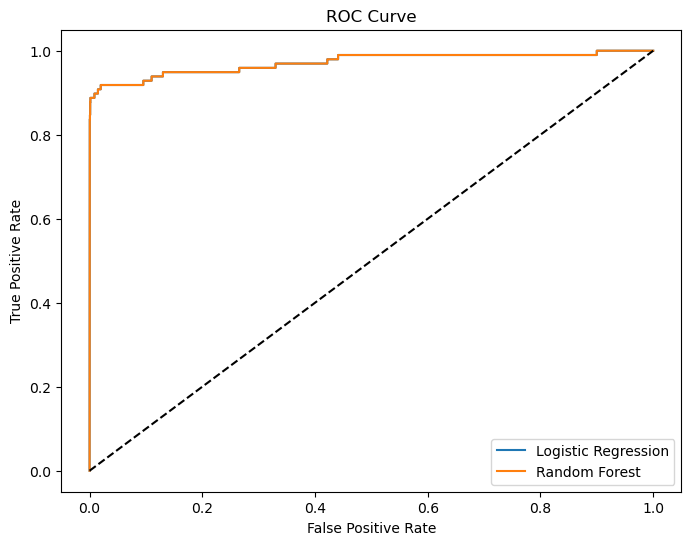

In [33]:
# ROC Curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
plt.figure(figsize=(8,6))

plt.plot(lr_fpr,
         lr_tpr,
         label='Logistic Regression')

plt.plot(rf_fpr,
         rf_tpr,
         label='Random Forest')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [41]:
# Feature Importance (Random Forest)

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance': abs(lr.coef_[0])
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
importance.head(15)

,Feature,Importance
28,Amount,2.340926
13,V14,1.782523
9,V10,1.603748
19,V20,1.401509
16,V17,1.300510
15,V16,1.239165
11,V12,1.215567
3,V4,1.040026
27,V28,1.010759
0,V1,0.996887


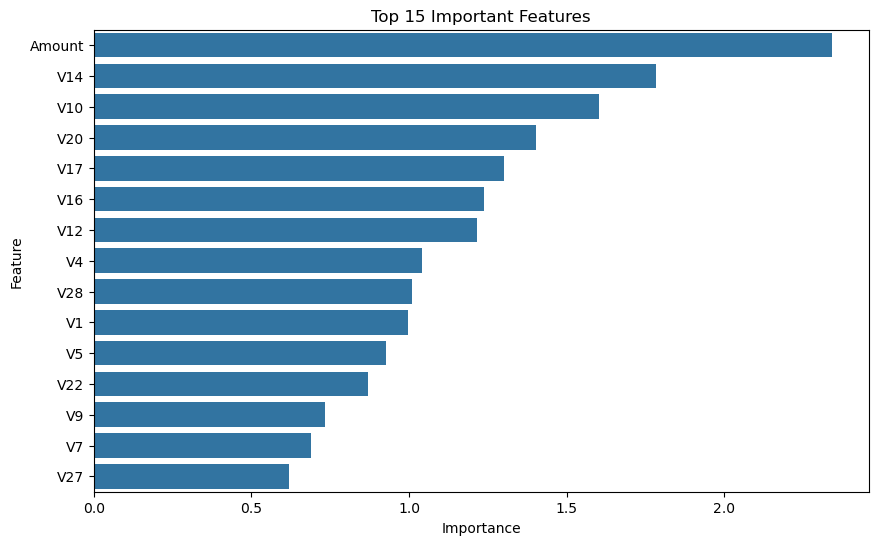

In [42]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(15)
)
plt.title("Top 15 Important Features")

plt.show()

In [43]:
# Logistic Regression Coefficients
coef = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':lr.coef_[0]
})

coef.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
28,Amount,2.340926
3,V4,1.040026
27,V28,1.010759
0,V1,0.996887
4,V5,0.927860
21,V22,0.870421
10,V11,0.543213
22,V23,0.540794
1,V2,0.487545
2,V3,0.379759


In [44]:
# Model Comparison
comparison = pd.DataFrame({

'Model':['Logistic Regression',
         'Random Forest'],

'Precision':[

precision_score(y_test,lr_pred),

precision_score(y_test,rf_pred)

],

'Recall':[

recall_score(y_test,lr_pred),

recall_score(y_test,rf_pred)

],

'F1 Score':[

f1_score(y_test,lr_pred),

f1_score(y_test,rf_pred)

],

'ROC AUC':[

roc_auc_score(y_test,lr_prob),

roc_auc_score(y_test,rf_prob)

]

})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.05618,0.918367,0.105882,0.971901
1,Random Forest,0.05618,0.918367,0.105882,0.971901
